# Class 1 - Phase identification - Single-Bus structure

## Agenda
- Problem Description
- Problem Implementation
- Alternative Problems
- Wrap-Up

## Problem Description

- While the connectivity model of low voltage (LV) grids is usually known, the phase connectivity information of single-phase connected customers is often erroneous or missing. This is due to many reasons including maintenance and other load balancing initiatives that usually do not update phase connectivity information and do not keep track of its changes in a systematic way.

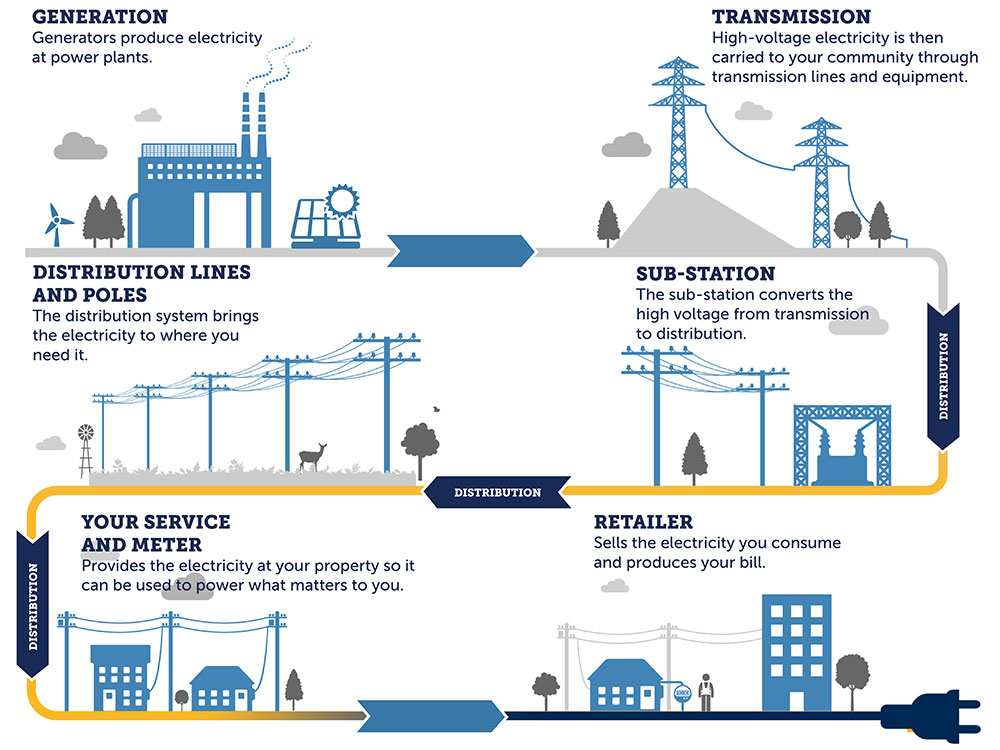
https://www.fortisalberta.com/about-us/our-company/blog/fortisalbertablog/2019/08/20/we-explain-the-complex-sophisticated-system-that-brings-electricity-to-you




- With the deployment of smart metering and the consequent availability
of high-resolution consumption data, phase connectivity
should be possible to estimate if data on per-phase aggregate energy
measurements would be available at substation sites with the
same resolutio.

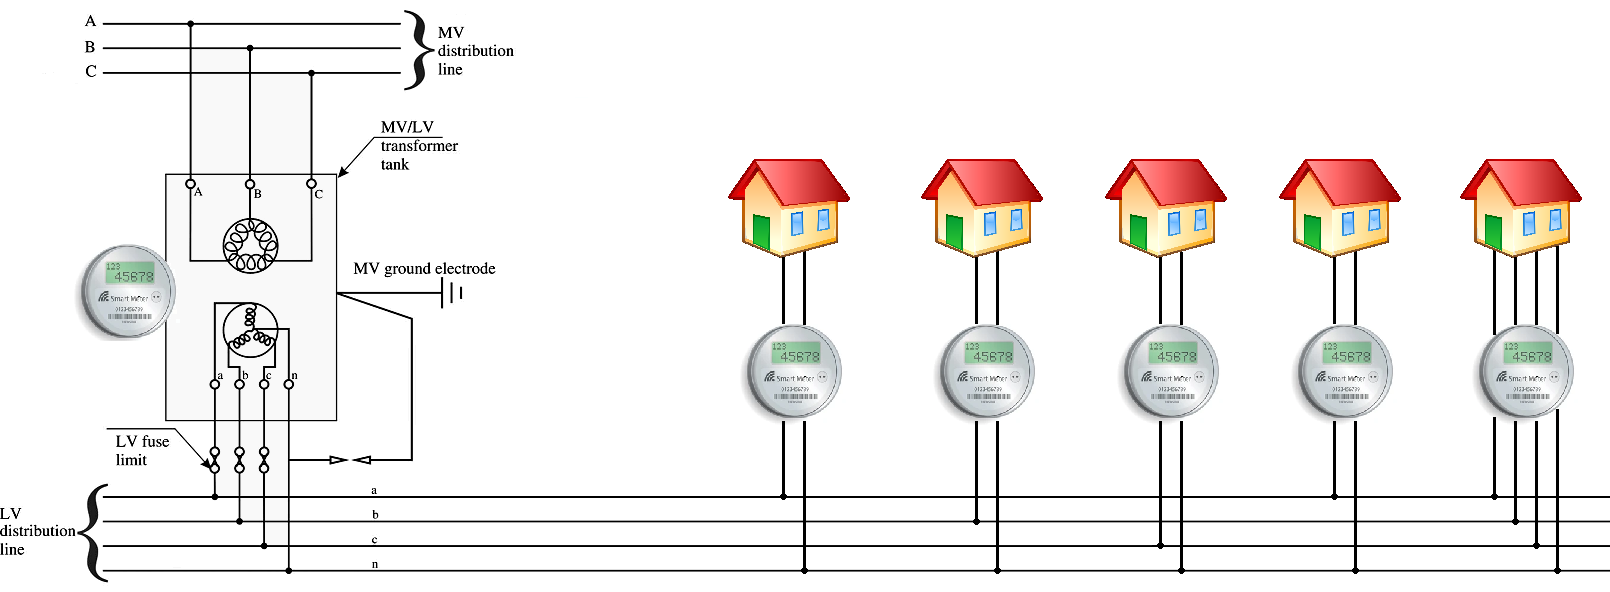

<b>Consider <i>N</i> customers whose connection phase assumes one out of three possible labels <i>a, b, </i> or <i> c</i> and estimate the correct customer-to-label assignment based on <i>M</i> readings whose per-phase values are a <i>function</i> of the corresponding phase-connected individual customer reading.</b>

## Problem Description

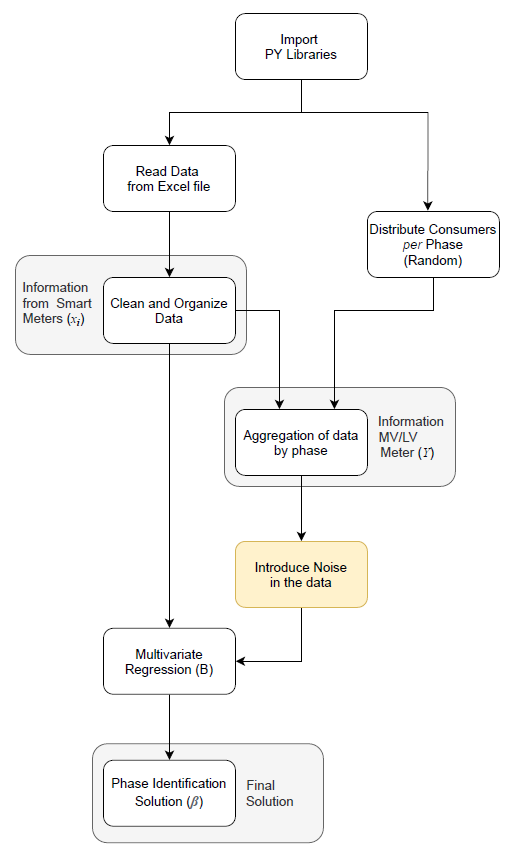

Import Python Libraries

In [92]:
import pandas as pd
import numpy as np
from numpy.random import randint   # To random values in the phases
from numpy.random import random   # To random values in the phases
import matplotlib.pyplot as plt
from numpy.linalg import inv, pinv


Parameters (It is possible to change to test different input data)

In [93]:
nc=4                        # Number of consumers (1 to nc)                  %%Data Notes: nc=4
ts=60                       #start period of analysis (Can be from 1 to 96)  %%Data Notes: ts=60
te=71                       #Last period of analysis (Can be from 1 to 96)   %%Data Notes: te=71
phase =[3,2,1,3]            #To obtain the same values of lecture notes
noise = 0
#phase = randint(1, 4, nc)  #To obtain random values

eps_error=0.01  # Error with variance 0.01

print ("The distribution of consumers in each phase is: ", phase)

The distribution of consumers in each phase is:  [3, 2, 1, 3]


Import data (From Excel file)

In [94]:
raw_data = np.array(pd.read_excel ('Prob1_Conso_Data.xlsx', header=None))

Clean and organize the data (delete zeros and organize by consumers)

In [95]:
checks=0
nr=1
data=np.zeros((1,96))
#h=np.arange(1/96, 1, 1/96).tolist()
h=raw_data[0:96,0]
for i in range(1,raw_data.shape[0]+1):
    if i==0:
        print(i)
    if raw_data[i-1,0]==h[checks]:
        checks=checks+1
    else:
        checks=0
    if checks==96:
        if np.sum(raw_data[i-96:i,1])!=0:
            data[nr-1,0:96]=raw_data[i-96:i,1]
            data.resize((nr+1,96))
            nr=nr+1
        checks=0
data.resize((nr-1,96))

data.shape[0]      #Can be deleted
print ("The number of consumers is ", data.shape[0], " and the number of periods is ", data.shape[1])

The number of consumers is  1390  and the number of periods is  96


Select data from consumers and period (Truncate the original matrix) 

In [96]:
data_Aux1=data[0:nc,:]
pw=data_Aux1[:,ts-1:te]

print ("The matrix 'pw' represents the power measured by the smart meter in each consumer (i) in each period (k)")
print ("In the lecture notes, this value is represented by X.")
print ("The value of X is:\n",np.transpose(4*pw))   # We should multiply by 4 to obtain the same values of the lectures. 
                                                    # In fact the original values are the average energy consumption for
                                                    # 15 minutes. To obtain the power, we should multiply by 4  


The matrix 'pw' represents the power measured by the smart meter in each consumer (i) in each period (k)
In the lecture notes, this value is represented by X.
The value of X is:
 [[0.332 0.064 0.084 0.12 ]
 [0.236 0.164 0.276 0.064]
 [0.224 0.708 1.572 0.072]
 [0.36  3.44  1.188 0.18 ]
 [1.332 2.176 0.484 1.464]
 [1.516 3.02  0.316 0.624]
 [0.92  0.916 0.404 2.772]
 [0.752 0.64  0.396 1.464]
 [1.828 0.684 0.576 0.576]
 [3.568 0.564 0.828 0.428]
 [0.78  0.356 0.728 0.348]
 [0.856 0.22  0.308 0.12 ]]


Consumers aggregation by phase and noise inclusion (normal distribution).

In [97]:
# Here I assume that we need to consider the values of the phases and then add noise to then try solving the problem for the phases we originally set
# This is a bit redundant, but it can be useful to understand the problem and the solution.
X = np.transpose(4*pw)
Y = np.zeros((X.shape[0], 3))  # To store the sum of the power in each phase and period

for k in range(X.shape[0]):
    for i in range(len(phase)):
        target_phase = phase[i] 
        phase_id = target_phase - 1
        
        eps=np.random.normal(0, 1)1, size=[1,1])*eps_error 

        Y[k, phase_id] += X[k, i] * (1 + float(eps))

print(X.shape[0])
print(Y)

SyntaxError: unmatched ')' (436606001.py, line 11)

Multivariate Regression 

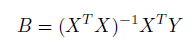

In [ ]:
# Ordinarily squared solves the linear system and we get the beta matrix

beta = inv(X.transpose() @ X) @ X.transpose() @ Y

print(beta)

[[ 3.38812760e-03 -1.49182598e-03  1.00108093e+00]
 [ 1.46627250e-03  9.99537886e-01  3.17587949e-03]
 [ 9.97700643e-01  1.08803463e-02 -9.49205442e-04]
 [-3.01311979e-04  5.10861889e-03  1.00757572e+00]]


First of all, I want to make a function that approximates the $\beta$ function to a matrix with only zeros and ones and checks if the phases match with the original phase vector.

In [ ]:
beta_perfect = beta.copy()
phases_result = np.array([0]*beta_perfect.shape[0])


for k in range(beta_perfect.shape[0]):
    max_idx = np.argmax(beta_perfect[k, :])
    phases_result[k] = max_idx + 1
    beta_perfect[k, :] = 0
    beta_perfect[k, max_idx] = 1

print(beta_perfect)
print("Resulting phases vector:" + str(phases_result))

# This returns a single True or False
are_identical = np.array_equal(phases_result, phase)

if are_identical:
    print("The phases match.")
else:
    print("The phases do not match.")

[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]
Resulting phases vector:[3 2 1 3]
The phases match.


Plot

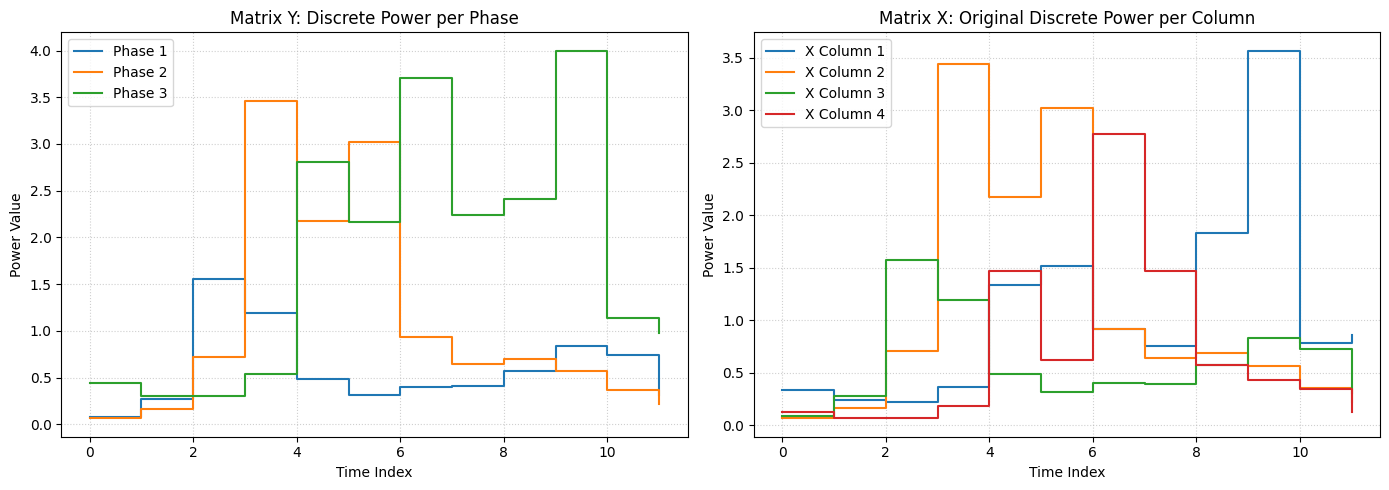

In [ ]:
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Matrix Y (Left Side) ---
for i in range(Y.shape[1]):
    ax1.step(np.arange(Y.shape[0]), Y[:, i], where='post', label=f'Phase {i+1}')

ax1.set_title('Matrix Y: Discrete Power per Phase')
ax1.set_xlabel('Time Index')
ax1.set_ylabel('Power Value')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Plot 2: Matrix X (Right Side) ---
for i in range(X.shape[1]):
    ax2.step(np.arange(X.shape[0]), X[:, i], where='post', label=f'X Column {i+1}')

ax2.set_title('Matrix X: Original Discrete Power per Column')
ax2.set_xlabel('Time Index')
ax2.set_ylabel('Power Value')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

# Adjust layout so titles/labels don't overlap
plt.tight_layout()
plt.show()

# Extra Challenges
Think about an interesting variation to this problem or a different way to solve and implement it !!!

Some ideas:
- What happens if we have two consumers with the same consumption ? What about if the difference is very small ? Can we quantify the sensitivity ?
- What happens if we have three-phase clients ? Can we follow the same approach ?

First let's create a function that generates X, Y and calculates $\beta$ depending on inputs:

(this is just what was done above put into a function that returns True or False depending on wether the input phase vector and created phase vectors match)

In [ ]:
def full_solve(nc, ts, te, phase, eps_error, data=data):
    data_Aux1=data[0:nc,:]
    pw=data_Aux1[:,ts-1:te]
    X = np.transpose(4*pw)

    Y = np.zeros((X.shape[0], 3))  # To store the sum of the power in each phase and period

    for k in range(X.shape[0]):
        for i in range(len(phase)):
            target_phase = phase[i] 
            phase_id = target_phase - 1
            
            eps = np.random.normal() * eps_error

            Y[k, phase_id] += X[k, i] * (1 + float(eps))
    
    beta = inv(X.transpose() @ X) @ X.transpose() @ Y

    beta_perfect = beta.copy()
    phases_result = np.array([0]*beta_perfect.shape[0])


    for k in range(beta_perfect.shape[0]):
        max_idx = np.argmax(beta_perfect[k, :])
        phases_result[k] = max_idx + 1
        beta_perfect[k, :] = 0
        beta_perfect[k, max_idx] = 1

    # This returns a single True or False
    are_identical = np.array_equal(phases_result, phase)

    return are_identical

def calculate_accuracy(test_func, iterations=100):
    # Run the passed-in function and store results as booleans
    results = [test_func() for _ in range(iterations)]
    
    # Calculate percentage
    accuracy = np.mean(results) * 100
    return accuracy


def test_variable_time(current_nc, eps_error, random_clients=False):
    if random_clients:
        current_nc = np.random.randint(1, current_nc)
    
    new_phase = np.random.randint(1, 4, current_nc)
    
    limit = 96 - current_nc
    new_ts = np.random.randint(1, max(2, limit)) 
    

    low_te = new_ts + current_nc
    high_te = max(low_te + 1, 97)
    new_te = np.random.randint(low_te, high_te)
    
    return full_solve(current_nc, new_ts, new_te, new_phase, eps_error)

### Varying Levels of Noise and Clients

In this section we'll vary the noise levels and see how it impacts the system. We will also vary the amount of clients.

Check sensitivity to noise with 4 clients and 12 points.

In [ ]:
new_eps_error = np.random.random() * 0.5

# We define what one single test run looks like
test_noise = lambda: full_solve(nc, ts, te, phase, new_eps_error)

accuracy = calculate_accuracy(test_noise, iterations=100)
print(f"Accuracy with random noise: {accuracy}%")   

Accuracy with random noise: 99.0%


Now let's see how this sensitivity varies as the number of clients increases.

Consumers: 4 | Accuracy: 100.0%
Consumers: 5 | Accuracy: 100.0%
Consumers: 6 | Accuracy: 100.0%
Consumers: 7 | Accuracy: 60.0%
Consumers: 8 | Accuracy: 47.0%
Consumers: 9 | Accuracy: 41.0%
Consumers: 10 | Accuracy: 30.0%
Consumers: 11 | Accuracy: 22.0%


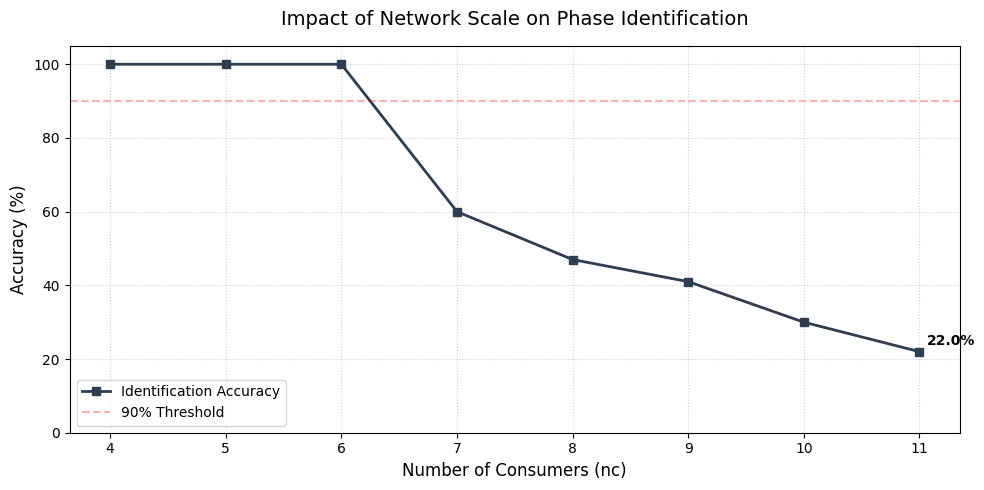

In [ ]:
eps_error=0.01

# 1. Initialize data containers
consumer_counts = []
accuracy_values = []

# 2. Run the simulation loop
for i in range(12 - nc):
    current_nc = nc + i
    
    # Define the test for this specific number of consumers
    # Note: Using a lambda to pass the varying nc into the accuracy calculator
    test_scale = lambda: full_solve(current_nc, ts, te, np.random.randint(1, 4, current_nc), eps_error)
    
    accuracy = calculate_accuracy(test_scale, iterations=100)
    
    # Store data for the plot
    consumer_counts.append(current_nc)
    accuracy_values.append(accuracy)
    
    print(f"Consumers: {current_nc} | Accuracy: {accuracy}%")

# 3. Visualization
plt.figure(figsize=(10, 5))

# Plotting the line with markers
plt.plot(consumer_counts, accuracy_values, marker='s', linestyle='-', color='#2c3e50', 
         linewidth=2, label='Identification Accuracy')

# Formatting aesthetics
plt.title('Impact of Network Scale on Phase Identification', fontsize=14, pad=15)
plt.xlabel('Number of Consumers (nc)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(consumer_counts)
plt.ylim(0, 105)
plt.grid(True, which='both', linestyle=':', alpha=0.6)

# Adding a horizontal line at 90% as a quality benchmark
plt.axhline(y=90, color='r', linestyle='--', alpha=0.3, label='90% Threshold')

# Annotating the final data point
plt.annotate(f'{accuracy_values[-1]}%', 
             xy=(consumer_counts[-1], accuracy_values[-1]), 
             xytext=(5, 5), textcoords='offset points', weight='bold')

plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

As we can see the reliability greatly decreases as the number of clients goes up. But what if we increase the number of sample points too, from 12 to 55?

In [ ]:
for i in range(12 - nc):
    current_nc = nc + i
    ts = 1
    te = 55
    # Define a test for this specific number of consumers
    test_scale = lambda: full_solve(current_nc, ts, te, np.random.randint(1, 4, current_nc), eps_error)
    
    accuracy = calculate_accuracy(test_scale, iterations=100)
    print(f"Consumers: {current_nc} | Accuracy: {accuracy}%")

Consumers: 4 | Accuracy: 100.0%
Consumers: 5 | Accuracy: 100.0%
Consumers: 6 | Accuracy: 100.0%
Consumers: 7 | Accuracy: 100.0%
Consumers: 8 | Accuracy: 100.0%
Consumers: 9 | Accuracy: 100.0%
Consumers: 10 | Accuracy: 100.0%
Consumers: 11 | Accuracy: 100.0%


And now setting a random time interval:

Consumers: 4 | Accuracy: 100.00%
Consumers: 5 | Accuracy: 100.00%
Consumers: 6 | Accuracy: 99.70%
Consumers: 7 | Accuracy: 88.40%
Consumers: 8 | Accuracy: 87.70%
Consumers: 9 | Accuracy: 87.70%
Consumers: 10 | Accuracy: 83.50%
Consumers: 11 | Accuracy: 85.00%


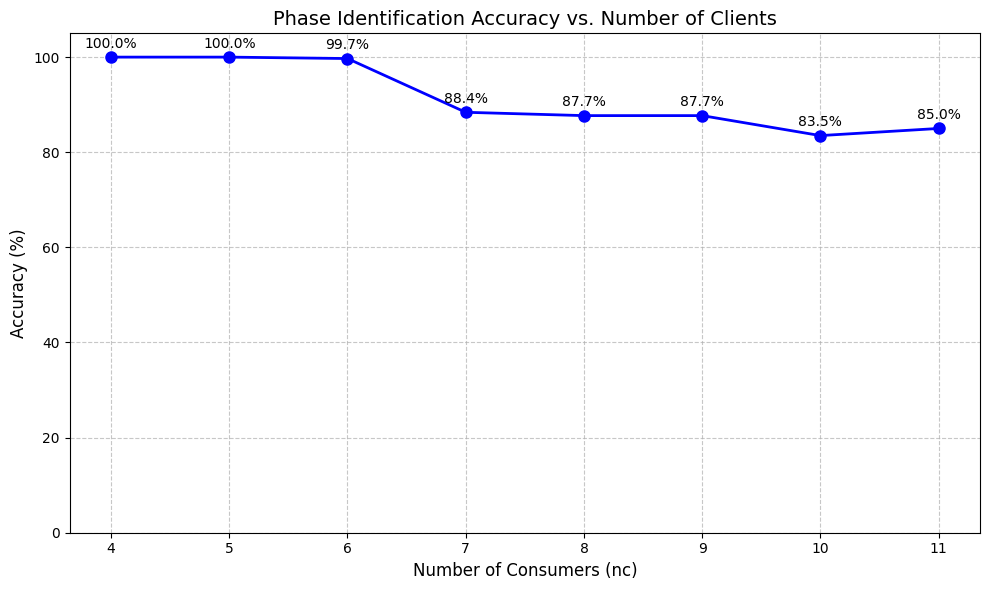

In [ ]:

# 1. Initialize lists to store our results
n_consumers = []
accuracies = []

# 2. Your loop logic
for i in range(12 - nc):
    current_nc = nc + i
    
    # Calculate accuracy
    accuracy = calculate_accuracy(lambda: test_variable_time(current_nc, eps_error), iterations=1000)
    
    # Store results for plotting
    n_consumers.append(current_nc)
    accuracies.append(accuracy)
    
    print(f"Consumers: {current_nc} | Accuracy: {accuracy:.2f}%")

# 3. Create the plot
plt.figure(figsize=(10, 6))
plt.plot(n_consumers, accuracies, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

# Formatting the chart
plt.title('Phase Identification Accuracy vs. Number of Clients', fontsize=14)
plt.xlabel('Number of Consumers (nc)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 105)  # Keeps the scale consistent (0-100%)
plt.xticks(n_consumers) # Ensures every client count is labeled

# Adding data labels on the points
for x, y in zip(n_consumers, accuracies):
    plt.text(x, y + 2, f'{y:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Now a last analysis, randomzing everything, even the number of clients (from 1-20):

In [ ]:
accuracy = calculate_accuracy(lambda: test_variable_time(20, eps_error, True), iterations=4000)
    
print(f"Accuracy: {accuracy:.2f}% (Across 4000 random time windows, errors and clients)")

Accuracy: 87.80% (Across 4000 random time windows, errors and clients)


### Two clients with the same consumption

Now we'll study what happens when there are two or more clients with the same consumption. The problem with this is that, if two columns of a matrix are the same, the matrix becomes singular, meaning that $X^T X$'s determinant is 0 and as such, $X^T X$ cannot be inverted. We have to instead use a pseudo-inverse, meaning that one of infinite solutions to the system will be found and used. If the consumptions varied even slightly, due to noise, this problem would not exist.

Physically, what this means is that, if two clients have exactly the same consumption, it's impossible to tell them apart and, as such, impossible to determine a singular specific value for $\beta$ that minimizes error in the system.

If both clients are on the same phase, this isn't a problem:

In [ ]:
phase_cloned =[3,3,2,1,3]   
ts = 20
te = 33


data_Aux1 = data[0:nc, :]
data_Aux1 = np.vstack([data_Aux1[0:1, :], data_Aux1])
pw = data_Aux1[:, ts-1:te]
X = np.transpose(4*pw)

print("Matrix X:\n", X)

Y = np.zeros((X.shape[0], 3))  # To store the sum of the power in each phase and period

for k in range(X.shape[0]):
    for i in range(len(phase_cloned)):
        target_phase = phase_cloned[i] 
        phase_id = target_phase - 1
        
        eps = np.random.normal(0, 1) * eps_error

        Y[k, phase_id] += X[k, i] * (1 + float(eps))

beta = pinv(X.transpose() @ X) @ X.transpose() @ Y

beta_perfect = beta.copy()
phases_result = np.array([0]*beta_perfect.shape[0])

print("Beta Matrix:\n", beta)

for k in range(beta_perfect.shape[0]):
    max_idx = np.argmax(beta_perfect[k, :])
    phases_result[k] = max_idx + 1
    beta_perfect[k, :] = 0
    beta_perfect[k, max_idx] = 1

# This returns a single True or False
are_identical = np.array_equal(phases_result, phase_cloned)

print("Phases Result:", are_identical)

Matrix X:
 [[0.076 0.076 0.064 0.192 0.064]
 [0.196 0.196 0.068 0.184 0.06 ]
 [0.192 0.192 0.064 0.064 0.128]
 [0.136 0.136 0.196 0.06  0.192]
 [0.068 0.068 0.192 0.06  0.176]
 [0.06  0.06  0.124 0.064 0.06 ]
 [0.064 0.064 0.064 0.108 0.064]
 [0.064 0.064 0.064 0.196 0.06 ]
 [0.16  0.16  0.06  0.18  0.06 ]
 [0.192 0.192 0.064 0.152 0.08 ]
 [0.224 0.224 0.196 0.068 0.196]
 [0.068 0.068 0.208 0.348 0.328]
 [0.1   0.1   0.22  1.52  1.08 ]
 [0.192 0.192 1.42  1.184 1.328]]
Beta Matrix:
 [[ 1.16288500e-03  3.80393819e-03  9.99293088e-01]
 [ 1.16288500e-03  3.80393819e-03  9.99293088e-01]
 [-4.12948750e-03  9.91767818e-01  1.18446082e-02]
 [ 1.00788250e+00  1.04669793e-03 -6.71449592e-03]
 [ 2.75281086e-03 -8.98191291e-04  1.01851776e+00]]
Phases Result: True


What happens if these clients are on different phases? Here, they cannot be distinguished mathematically, so it's impossible to tell which is in which phase.

In [ ]:
phase_cloned =[3,1,2,1,3]   

data_Aux1 = data[0:nc, :]
data_Aux1 = np.vstack([data_Aux1[0:1, :], data_Aux1])
pw = data_Aux1[:, ts-1:te]
X = np.transpose(4*pw)

print("Matrix X:\n", X)

Y = np.zeros((X.shape[0], 3))  # To store the sum of the power in each phase and period

for k in range(X.shape[0]):
    for i in range(len(phase_cloned)):
        target_phase = phase_cloned[i] 
        phase_id = target_phase - 1
        
        eps = np.random.normal(0, 1) * eps_error

        Y[k, phase_id] += X[k, i] * (1 + float(eps))

beta = pinv(X.transpose() @ X) @ X.transpose() @ Y

beta_perfect = beta.copy()
phases_result = np.array([0]*beta_perfect.shape[0])

print("Beta Matrix:\n", beta)

for k in range(beta_perfect.shape[0]):
    max_idx = np.argmax(beta_perfect[k, :])
    phases_result[k] = max_idx + 1
    beta_perfect[k, :] = 0
    beta_perfect[k, max_idx] = 1

# This returns a single True or False
are_identical = np.array_equal(phases_result, phase_cloned)

print("Phases Result:", are_identical)

Matrix X:
 [[0.076 0.076 0.064 0.192 0.064]
 [0.196 0.196 0.068 0.184 0.06 ]
 [0.192 0.192 0.064 0.064 0.128]
 [0.136 0.136 0.196 0.06  0.192]
 [0.068 0.068 0.192 0.06  0.176]
 [0.06  0.06  0.124 0.064 0.06 ]
 [0.064 0.064 0.064 0.108 0.064]
 [0.064 0.064 0.064 0.196 0.06 ]
 [0.16  0.16  0.06  0.18  0.06 ]
 [0.192 0.192 0.064 0.152 0.08 ]
 [0.224 0.224 0.196 0.068 0.196]
 [0.068 0.068 0.208 0.348 0.328]
 [0.1   0.1   0.22  1.52  1.08 ]
 [0.192 0.192 1.42  1.184 1.328]]
Beta Matrix:
 [[ 0.5078176   0.0010316   0.50227259]
 [ 0.5078176   0.0010316   0.50227259]
 [-0.01503899  0.99981817 -0.0015705 ]
 [ 1.00480654 -0.00179981  0.00323446]
 [ 0.01591343  0.00581054  1.01430096]]
Phases Result: False


As one last note, even if the consumptions vary slightly due to noise,  the system can still be wrong and unable to distinguish the phases in which these consumers are, due to rounding errors and the nature of the problem being an error minimisation problem and not a unique solution problem. We can check this by adding random noise to the second, cloned column:

Noise Level: 0.0001 | Accuracy: 36.40%
Noise Level: 0.0002 | Accuracy: 66.00%
Noise Level: 0.0003 | Accuracy: 78.60%
Noise Level: 0.0004 | Accuracy: 84.60%
Noise Level: 0.0005 | Accuracy: 93.00%
Noise Level: 0.0006 | Accuracy: 96.40%
Noise Level: 0.0007 | Accuracy: 97.60%
Noise Level: 0.0008 | Accuracy: 99.60%
Noise Level: 0.0009 | Accuracy: 99.20%
Noise Level: 0.0010 | Accuracy: 99.80%


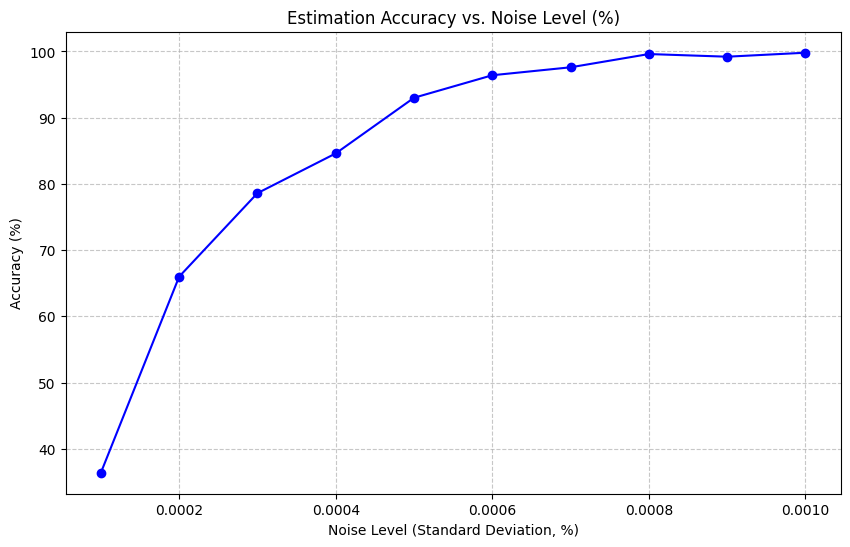

In [ ]:
def test_imperfect_cloning(noise_level=0.0001):

    phase_cloned =[3,1,2,1,3]   

    data_Aux1 = data[0:nc, :]

    cloned_row = data_Aux1[0:1, :] 
    noise = np.random.normal(0, noise_level, size=cloned_row.shape)
    cloned_row_with_noise = cloned_row + noise

    data_Aux1 = np.vstack([cloned_row_with_noise, data_Aux1])

    pw = data_Aux1[:, ts-1:te]
    X = np.transpose(4 * pw)


    Y = np.zeros((X.shape[0], 3))  # To store the sum of the power in each phase and period

    for k in range(X.shape[0]):
        for i in range(len(phase_cloned)):
            target_phase = phase_cloned[i] 
            phase_id = target_phase - 1
            
            eps = np.random.normal(0, 1) * eps_error

            Y[k, phase_id] += X[k, i] * (1 + float(eps))

    beta = pinv(X.transpose() @ X) @ X.transpose() @ Y

    beta_perfect = beta.copy()
    phases_result = np.array([0]*beta_perfect.shape[0])


    for k in range(beta_perfect.shape[0]):
        max_idx = np.argmax(beta_perfect[k, :])
        phases_result[k] = max_idx + 1
        beta_perfect[k, :] = 0
        beta_perfect[k, max_idx] = 1

    # This returns a single True or False
    are_identical = np.array_equal(phases_result, phase_cloned)

    return are_identical

# 1. Define the range of noise levels to test
noise_levels = np.linspace(0.0001, 0.001, 10)  # 10 values from 0.0001 to 0.1
accuracies = []
iterations_per_level = 500  # How many times to test each noise level

# 2. Loop through each noise level and calculate accuracy
for level in noise_levels:
    successes = 0
    for _ in range(iterations_per_level):
        if test_imperfect_cloning(noise_level=level):
            successes += 1
    
    acc = (successes / iterations_per_level) * 100
    accuracies.append(acc)
    print(f"Noise Level: {level:.4f} | Accuracy: {acc:.2f}%")

# 3. Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(noise_levels, accuracies, marker='o', linestyle='-', color='b')
plt.title('Estimation Accuracy vs. Noise Level (%)')
plt.xlabel('Noise Level (Standard Deviation, %)')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

As we can see, our prediction was only right about 50% of the time (which makes sense since there are two cloned columns.)

### Three phase client

Now for a three phase client, we need to create a Y matrix taking into account an arbitrary phase distribuition for this client, say, 50% on phase a, 20% on phase b and 30% on phase c. Then, after creating the Y matrix, we go back and subtract 1/3 of the total three phase client's consumption from each Y matrix's column, since we assume that the consumption is evenly distributed by phases.

In [103]:
nc = 4
phases =[3,2,1,3]
phases_threep = [0.50, 0.20, 0.30]

data_Aux1 = data[0:nc+1, :]
pw = data_Aux1[:, ts-1:te]
X_temp = np.transpose(4*pw)

Y = np.zeros((X_temp.shape[0], 3))  # To store the sum of the power in each phase and period

for k in range(X_temp.shape[0]): 
    for i in range(len(phases)+1):
        
        # Check if this is the last client (the three-phase one)
        if i == len(phases):
            for phase_idx, weight in enumerate(phases_threep):
                eps = np.random.normal(0, 1) * eps_error # Centered at 0 for noise
                # Distribute the power across all 3 phases based on weight
                Y[k, phase_idx] += (X_temp[k, i] * weight) + float(eps)
        
        else:
            # Normal single-phase logic for all other clients
            target_phase = phases[i] 
            phase_id = target_phase - 1
            eps = np.random.normal(0, 1) * eps_error
            
            Y[k, phase_id] += X_temp[k, i] * (1 + float(eps))

# Assuming phases_threep is a list of lists or a numpy array
# n is the number of 3-phase items (4 in your example)
n = len(phases_threep)

# We iterate through the last n columns of X_temp
for i in range(n):
    # column_idx maps to the actual column position in X_temp
    column_idx = X_temp.shape[1] - n + i
       
    # Subtract the weighted contribution from each phase in Y
    Y[:, 0] -= X_temp[:, column_idx] * 1/3
    Y[:, 1] -= X_temp[:, column_idx] * 1/3
    Y[:, 2] -= X_temp[:, column_idx] * 1/3
    
data_Aux1 = data[0:nc, :]
pw = data_Aux1[:, ts-1:te]
X = np.transpose(4*pw)

beta = pinv(X.transpose() @ X) @ X.transpose() @ Y

beta_perfect = beta.copy()
phases_result = np.array([0]*beta_perfect.shape[0])

print("Beta Matrix:\n", beta)

for k in range(beta_perfect.shape[0]):
    max_idx = np.argmax(beta_perfect[k, :])
    phases_result[k] = max_idx + 1
    beta_perfect[k, :] = 0
    beta_perfect[k, max_idx] = 1


Beta Matrix:
 [[-6.11441111e-04 -3.15527999e-03  9.93113429e-01]
 [ 3.06969616e-03  1.00489748e+00  5.89245723e-03]
 [ 6.87675593e-01 -3.44122833e-01 -3.42471444e-01]
 [-3.32362603e-01 -3.43678454e-01  6.69346667e-01]]


We can see that the results are still pretty good. Let's add more and more unbalanced three phase clients now.

In [104]:
nc = 4
phases =[3,2,1,3]
phases_threep = [[0.50, 0.20, 0.30], [0.40, 0.40, 0.20], [0.80, 0.10, 0.10], [0.90, 0.05, 0.05]]

data_Aux1 = data[0:nc+len(phases_threep), :]
pw = data_Aux1[:, ts-1:te]
X_temp = np.transpose(4*pw)

print("Matrix X:\n", X)

Y = np.zeros((X_temp.shape[0], 3))  # To store the sum of the power in each phase and period

for k in range(X_temp.shape[0]): 
    for i in range(X_temp.shape[1]): # Iterate through all columns/clients
        
        # Check if the current index corresponds to a three-phase client
        if i >= len(phases):
            # Calculate which vector in phases_threep to use
            tp_idx = i - len(phases) 
            weights = phases_threep[tp_idx]
            
            for phase_id, weight in enumerate(weights):
                eps = np.random.normal(0, 1) * eps_error
                # Distribute X[k, i] across the 3 phases using the specific weight
                Y[k, phase_id] += (X_temp[k, i] * weight) + float(eps)
        
        else:
            # Normal single-phase logic
            target_phase = phases[i] 
            phase_id = target_phase - 1
            eps = np.random.normal(0, 1) * eps_error
            Y[k, phase_id] += X_temp[k, i] * (1 + float(eps))

# Assuming phases_threep is a list of lists or a numpy array
# n is the number of 3-phase items (4 in your example)
n = len(phases_threep)

# We iterate through the last n columns of X_temp
for i in range(n):
    # column_idx maps to the actual column position in X_temp
    column_idx = X_temp.shape[1] - n + i
       
    # Subtract the weighted contribution from each phase in Y
    Y[:, 0] -= X_temp[:, column_idx] * 1/3
    Y[:, 1] -= X_temp[:, column_idx] * 1/3
    Y[:, 2] -= X_temp[:, column_idx] * 1/3

data_Aux1 = data[0:nc, :]
pw = data_Aux1[:, ts-1:te]
X = np.transpose(4*pw)

beta = pinv(X.transpose() @ X) @ X.transpose() @ Y

beta_perfect = beta.copy()
phases_result = np.array([0]*beta_perfect.shape[0])

print("Beta Matrix:\n", beta)

for k in range(beta_perfect.shape[0]):
    max_idx = np.argmax(beta_perfect[k, :])
    phases_result[k] = max_idx + 1
    beta_perfect[k, :] = 0
    beta_perfect[k, max_idx] = 1


Matrix X:
 [[0.332 0.064 0.084 0.12 ]
 [0.236 0.164 0.276 0.064]
 [0.224 0.708 1.572 0.072]
 [0.36  3.44  1.188 0.18 ]
 [1.332 2.176 0.484 1.464]
 [1.516 3.02  0.316 0.624]
 [0.92  0.916 0.404 2.772]
 [0.752 0.64  0.396 1.464]
 [1.828 0.684 0.576 0.576]
 [3.568 0.564 0.828 0.428]
 [0.78  0.356 0.728 0.348]
 [0.856 0.22  0.308 0.12 ]]
Beta Matrix:
 [[-1.36631037e-04  7.96353730e-04  9.86842464e-01]
 [ 1.48413002e-02  1.00050237e+00 -8.66795371e-03]
 [ 1.10632610e+00 -5.66904830e-02 -3.82000450e-02]
 [ 5.77802789e-02 -1.90751213e-02  9.72500193e-01]]
